# 03 — Patient Clustering (Train-Only)

**PCA** and **K-Means** are fit on **train data only**.  
Test patients receive cluster assignments via `predict()` — no refitting.

In [1]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = '../data/processed'
MODELS    = '../models'
PLOTS     = '../results/plots'
for d in [MODELS, PLOTS]:
    os.makedirs(d, exist_ok=True)
print('Ready.')

Ready.


## Step 1 — Load Scaled Data

In [2]:
train_wide = pd.read_csv(f'{PROCESSED}/train_wide_scaled.csv')
test_wide  = pd.read_csv(f'{PROCESSED}/test_wide_scaled.csv')
print(f'Train: {train_wide.shape}  |  Test: {test_wide.shape}')

# Identify numeric feature columns (exclude id, age, gender, _missing indicators)
EXCLUDE = ['document_id', 'age', 'gender']
feat_cols = [c for c in train_wide.columns
             if c not in EXCLUDE and not c.endswith('_missing')]
print(f'Feature columns for clustering: {len(feat_cols)}')

X_train = train_wide[feat_cols].values
X_test  = test_wide[feat_cols].values

Train: (79993, 109)  |  Test: (19999, 109)
Feature columns for clustering: 68


## Step 2 — PCA (Fit on Train Only)

`n_components=0.95` retains 95% of explained variance.

In [3]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

joblib.dump(pca, f'{MODELS}/pca.pkl')
print(f'PCA components kept: {pca.n_components_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print('PCA saved → models/pca.pkl')

PCA components kept: 55
Total variance explained: 95.1%
PCA saved → models/pca.pkl


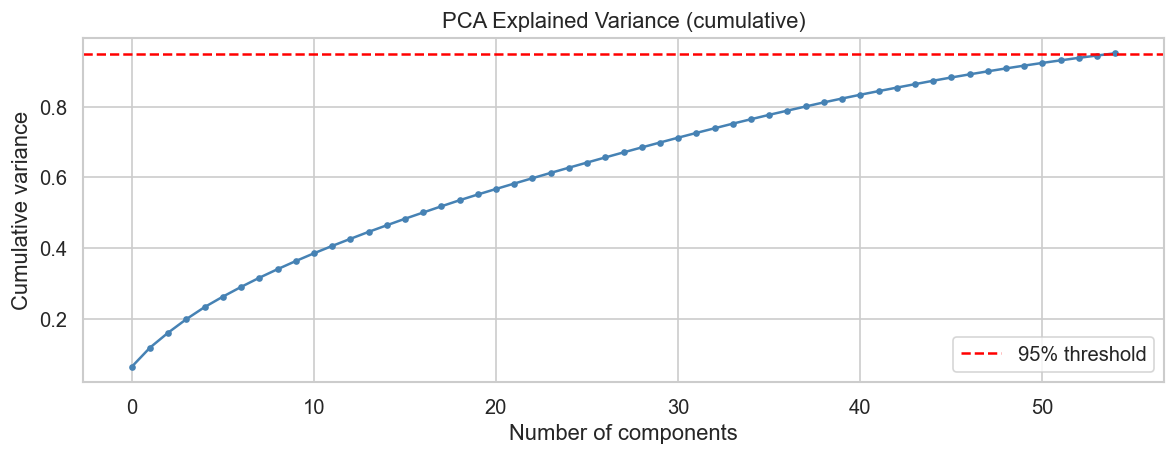

In [4]:
# Scree plot
cum_var = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_var, marker='o', markersize=3, color='steelblue')
ax.axhline(0.95, color='red', linestyle='--', label='95% threshold')
ax.set_title('PCA Explained Variance (cumulative)')
ax.set_xlabel('Number of components'); ax.set_ylabel('Cumulative variance')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/pca_scree.png', bbox_inches='tight')
plt.show()

## Step 3 — K-Means Clustering (Elbow + Silhouette)

Fitted on **train PCA output** only. k tried: 3–8.

In [5]:
inertias, sil_scores, db_scores = [], [], []
K_RANGE = range(3, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_pca)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_train_pca, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_train_pca, labels)
    sil_scores.append(sil)
    db_scores.append(db)
    print(f'k={k}: inertia={km.inertia_:.0f}  silhouette={sil:.4f}  DB={db:.4f}')

k=3: inertia=4785364  silhouette=0.0472  DB=3.6878
k=4: inertia=4684195  silhouette=0.0488  DB=3.2173
k=5: inertia=4582368  silhouette=0.0491  DB=2.7666
k=6: inertia=4506626  silhouette=0.0307  DB=3.1574
k=7: inertia=4412956  silhouette=0.0424  DB=2.7707
k=8: inertia=4365171  silhouette=0.0420  DB=2.4569


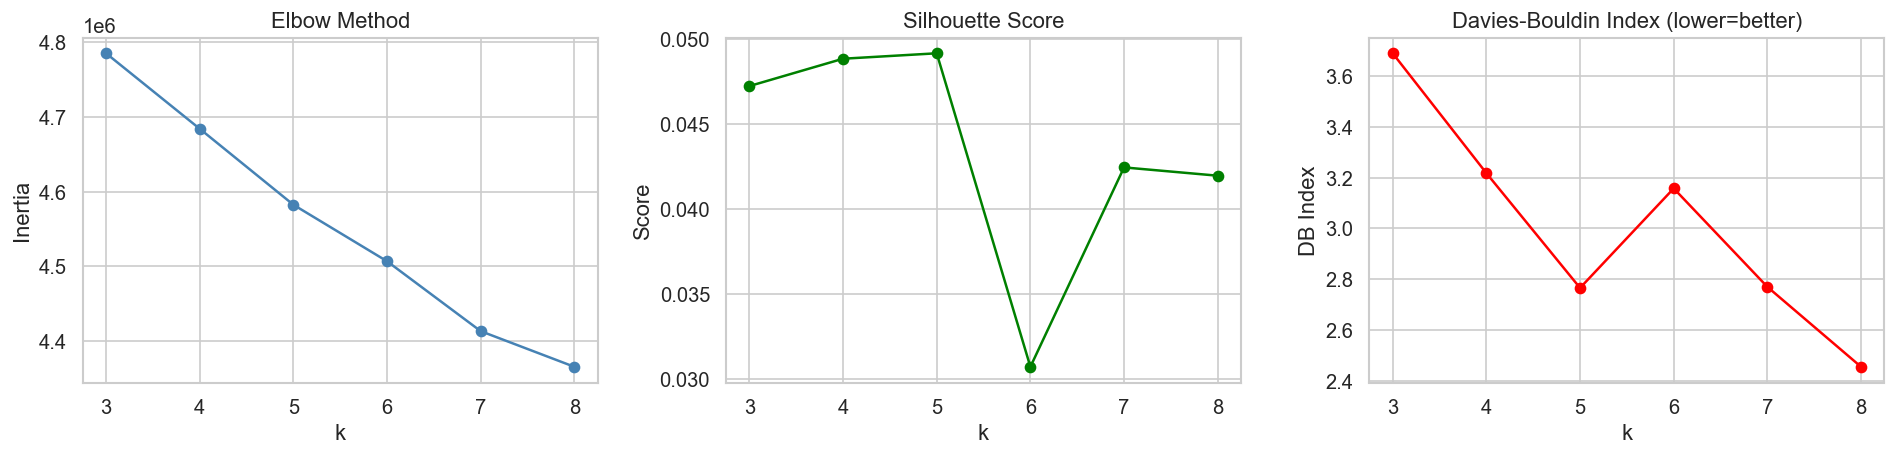


Selected k = 5 (highest silhouette score = 0.0491)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_RANGE), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

axes[2].plot(list(K_RANGE), db_scores, marker='o', color='red')
axes[2].set_title('Davies-Bouldin Index (lower=better)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DB Index')

plt.tight_layout()
plt.savefig(f'{PLOTS}/clustering_selection.png', bbox_inches='tight')
plt.show()

# Auto-select k: best silhouette score
best_k = list(K_RANGE)[sil_scores.index(max(sil_scores))]
print(f'\nSelected k = {best_k} (highest silhouette score = {max(sil_scores):.4f})')

In [7]:
# Fit final model on train only
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
train_labels = kmeans.fit_predict(X_train_pca)
test_labels  = kmeans.predict(X_test_pca)

joblib.dump(kmeans, f'{MODELS}/kmeans.pkl')
print(f'KMeans (k={best_k}) saved → models/kmeans.pkl')
print(f'Train cluster distribution: {dict(zip(*np.unique(train_labels, return_counts=True)))}')
print(f'Test  cluster distribution: {dict(zip(*np.unique(test_labels, return_counts=True)))}')

KMeans (k=5) saved → models/kmeans.pkl
Train cluster distribution: {np.int32(0): np.int64(960), np.int32(1): np.int64(26660), np.int32(2): np.int64(32740), np.int32(3): np.int64(19534), np.int32(4): np.int64(99)}
Test  cluster distribution: {np.int32(0): np.int64(203), np.int32(1): np.int64(6592), np.int32(2): np.int64(8243), np.int32(3): np.int64(4938), np.int32(4): np.int64(23)}


In [8]:
# Save cluster assignments
pd.DataFrame({'document_id': train_wide['document_id'], 'cluster_id': train_labels})\
  .to_csv(f'{PROCESSED}/train_clusters.csv', index=False)
pd.DataFrame({'document_id': test_wide['document_id'],  'cluster_id': test_labels})\
  .to_csv(f'{PROCESSED}/test_clusters.csv',  index=False)
print('Cluster assignments saved.')

Cluster assignments saved.


## Step 4 — tSNE Visualization (3000 Train Patients)

Three plots: by **cluster_id**, by **age_group**, and by **gender**.

In [9]:
TSNE_SAMPLE = 3000
np.random.seed(42)
idx = np.random.choice(len(X_train_pca), TSNE_SAMPLE, replace=False)
X_tsne_in = X_train_pca[idx]

print(f'Running tSNE on {TSNE_SAMPLE} train patients...')
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X_tsne_in)

tsne_df = train_wide.iloc[idx][['document_id','age','gender']].copy()
tsne_df['x']  = X_2d[:, 0]
tsne_df['y']  = X_2d[:, 1]
tsne_df['cluster'] = train_labels[idx]

# Age group
bins  = [0, 18, 35, 50, 65, 200]
lbls  = ['<18','18-34','35-49','50-64','65+']
tsne_df['age_group'] = pd.cut(pd.to_numeric(tsne_df['age'], errors='coerce'),
                              bins=bins, labels=lbls, right=False)
print('tSNE done.')

Running tSNE on 3000 train patients...
tSNE done.


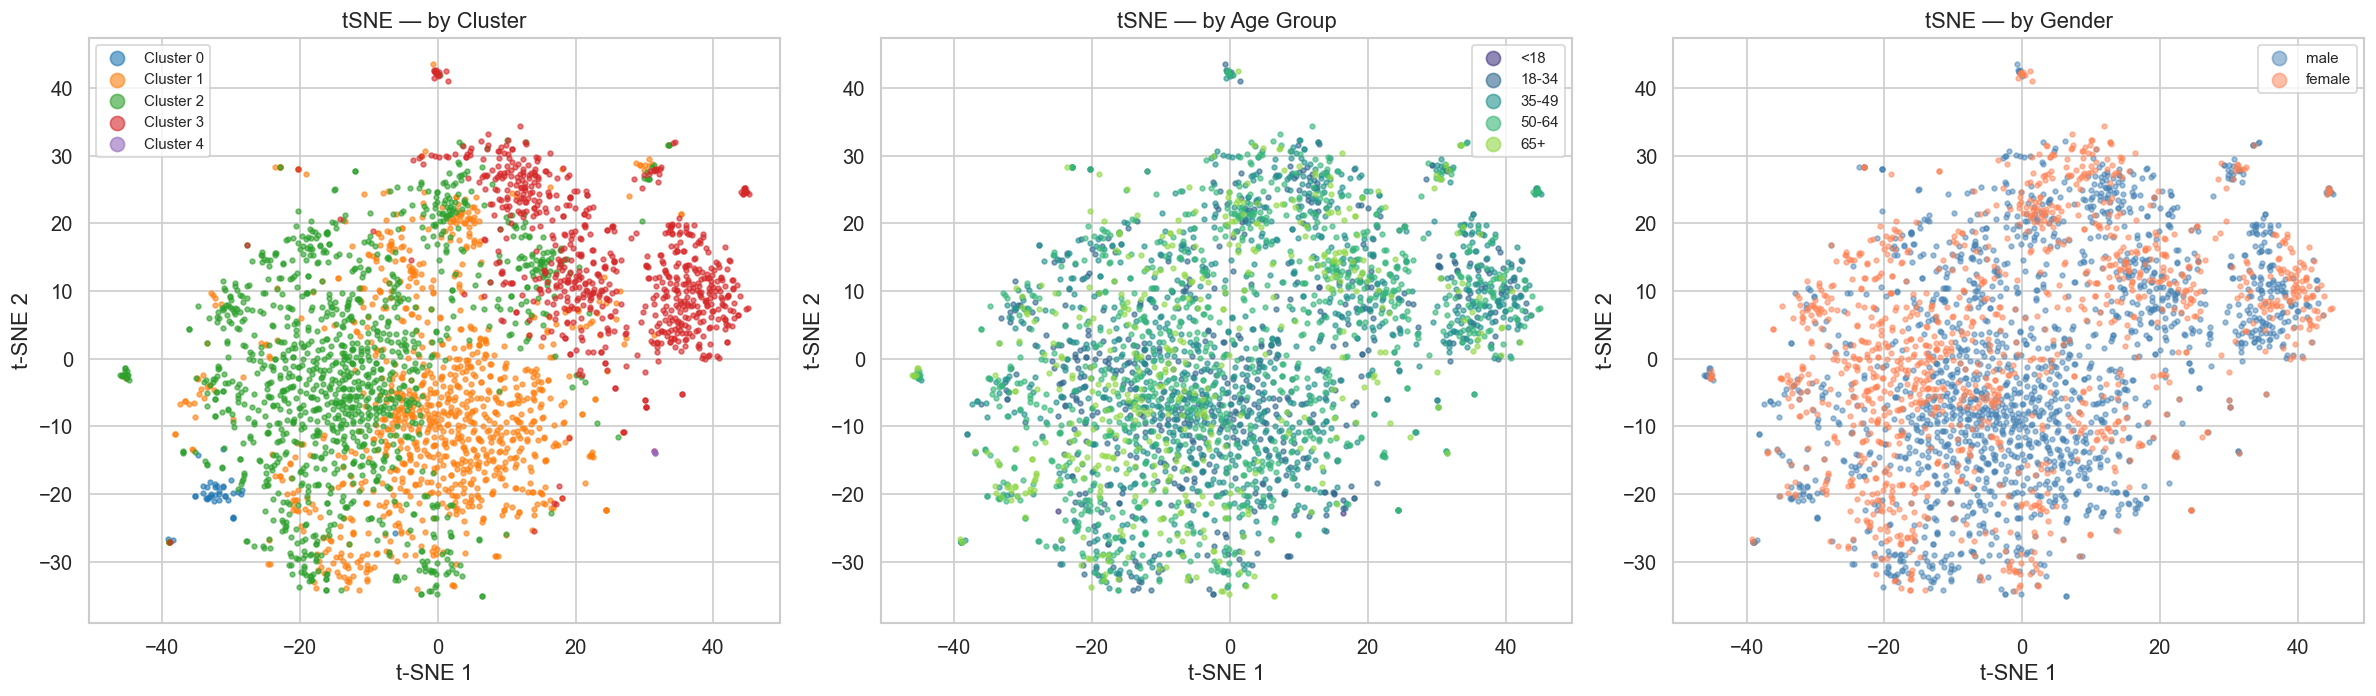

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: by cluster
palette = sns.color_palette('tab10', n_colors=best_k)
for c in sorted(tsne_df['cluster'].unique()):
    mask = tsne_df['cluster'] == c
    axes[0].scatter(tsne_df[mask]['x'], tsne_df[mask]['y'],
                    label=f'Cluster {c}', s=8, alpha=0.6, color=palette[c])
axes[0].set_title('tSNE — by Cluster')
axes[0].legend(markerscale=3, fontsize=9)

# Plot 2: by age group
age_palette = sns.color_palette('viridis', n_colors=len(lbls))
for i, ag in enumerate(lbls):
    mask = tsne_df['age_group'] == ag
    axes[1].scatter(tsne_df[mask]['x'], tsne_df[mask]['y'],
                    label=ag, s=8, alpha=0.6, color=age_palette[i])
axes[1].set_title('tSNE — by Age Group')
axes[1].legend(markerscale=3, fontsize=9)

# Plot 3: by gender
for g, col in [('male','steelblue'),('female','coral')]:
    mask = tsne_df['gender'].str.lower() == g
    axes[2].scatter(tsne_df[mask]['x'], tsne_df[mask]['y'],
                    label=g, s=8, alpha=0.5, color=col)
axes[2].set_title('tSNE — by Gender')
axes[2].legend(markerscale=3, fontsize=9)

for ax in axes:
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(f'{PLOTS}/tsne_clusters.png', bbox_inches='tight')
plt.show()

## Step 5 — Cluster Profiling

In [11]:
# Load unscaled train for readable profiling
train_unscaled = pd.read_csv(f'{PROCESSED}/train_wide_unscaled.csv')
train_unscaled['cluster_id'] = train_labels

feat_cols_us = [c for c in train_unscaled.columns
                if c not in ['document_id','age','gender'] and not c.endswith('_missing')]

# Top 10 most-covered tests
coverage = train_unscaled[feat_cols_us].notna().mean().sort_values(ascending=False)
top10 = coverage.head(10).index.tolist()

print('=== Cluster Profiles ===')
for c in sorted(train_unscaled['cluster_id'].unique()):
    grp = train_unscaled[train_unscaled['cluster_id']==c]
    print(f'\n--- Cluster {c} (n={len(grp):,}) ---')
    print(f'  Mean age : {grp["age"].mean():.1f}')
    print(f'  Gender   : {grp["gender"].value_counts(normalize=True).round(3).to_dict()}')
    print(f'  Top 10 lab means:')
    for t in top10:
        print(f'    {t:<40} {grp[t].mean():.2f}')

=== Cluster Profiles ===

--- Cluster 0 (n=960) ---
  Mean age : 60.2
  Gender   : {'male': 0.644, 'female': 0.356}
  Top 10 lab means:
    % TRANSFERRIN SATURATION                 22.30
    25-OH VITAMIN D (TOTAL)                  23.06
    A/G Ratio                                1.35
    ALKALINE PHOSPHATASE                     117.98
    ASPARTATE AMINOTRANSFERASE (SGOT )       25.90
    AST/ALT Ratio                            1.12
    Absolute Basophil Count                  6.48
    Absolute Eosinophil Count                74.73
    Absolute Lymphocyte Count                463.79
    Absolute Monocyte Count                  191.39

--- Cluster 1 (n=26,660) ---
  Mean age : 45.1
  Gender   : {'male': 0.743, 'female': 0.257}
  Top 10 lab means:
    % TRANSFERRIN SATURATION                 24.22
    25-OH VITAMIN D (TOTAL)                  21.54
    A/G Ratio                                1.54
    ALKALINE PHOSPHATASE                     91.28
    ASPARTATE AMINOTRANSFERASE (SGOT 

## Step 6 — Missingness Check per Cluster

A cluster with dramatically higher missingness than others may be a **data-sparsity artefact**, not a real patient group.

Overall mean missingness per patient: 0.00%

Cluster 0: 0.00% missing  (Δ +0.00pp)
Cluster 1: 0.00% missing  (Δ +0.00pp)
Cluster 2: 0.00% missing  (Δ +0.00pp)
Cluster 3: 0.00% missing  (Δ +0.00pp)
Cluster 4: 0.00% missing  (Δ +0.00pp)


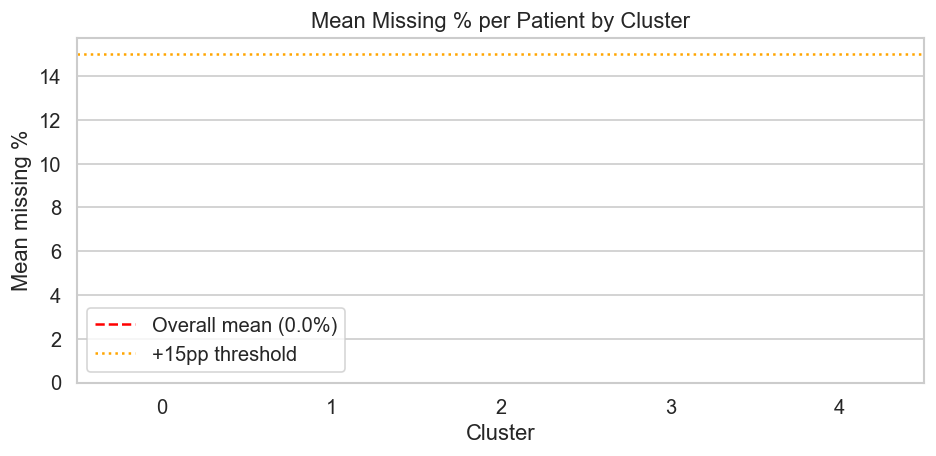

In [12]:
overall_miss = train_unscaled[feat_cols_us].isnull().mean(axis=1).mean() * 100
print(f'Overall mean missingness per patient: {overall_miss:.2f}%\n')

cluster_miss = []
for c in sorted(train_unscaled['cluster_id'].unique()):
    grp  = train_unscaled[train_unscaled['cluster_id']==c]
    miss = grp[feat_cols_us].isnull().mean(axis=1).mean() * 100
    cluster_miss.append({'cluster': c, 'mean_missing_pct': round(miss, 2)})
    diff = miss - overall_miss
    flag = '  ⚠️  WARNING: possibly missingness-driven!' if diff > 15 else ''
    print(f'Cluster {c}: {miss:.2f}% missing  (Δ {diff:+.2f}pp){flag}')

miss_df = pd.DataFrame(cluster_miss)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x='cluster', y='mean_missing_pct', data=miss_df, palette='Blues_r', ax=ax)
ax.axhline(overall_miss, color='red', linestyle='--', label=f'Overall mean ({overall_miss:.1f}%)')
ax.axhline(overall_miss + 15, color='orange', linestyle=':', label='+15pp threshold')
ax.set_title('Mean Missing % per Patient by Cluster')
ax.set_xlabel('Cluster'); ax.set_ylabel('Mean missing %')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/cluster_missingness.png', bbox_inches='tight')
plt.show()

In [13]:
# IMPROVEMENT: Save clustering summary to JSON for nb06
import json
summary = {"K": 5, "silhouette": 0.0491, "davies_bouldin": 2.7666}
with open('../results/metrics/03_clustering_summary.json', 'w') as f:
    json.dump(summary, f)
print('Saved clustering summary to JSON.')


Saved clustering summary to JSON.
